In [1]:
# ============================================================
#  环境配置
#  - Colab 用户：取消注释下方 Colab 区块
#  - 本地 Jupyter 用户：直接运行 Local 区块
# ============================================================

# ── Colab 环境（取消注释后运行） ──
!pip install torch torchvision matplotlib numpy -U -q

# ── 本地 Jupyter 环境 ──
# import subprocess, sys
# def _install(pkg):
#     subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# _install("torch==2.6.0")
# _install("torchvision==0.21.0")
# _install("matplotlib==3.9.4")
# _install("numpy==1.26.4")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 106.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.2 which is incompatible.


In [2]:
import math, copy
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


# Masked Autoencoders (MAE) 从零到一：源代码实现 vs 简洁实现

基于论文 *Masked Autoencoders Are Scalable Vision Learners* (He et al., 2021)，
用 **自监督图像重建** 任务演示 MAE 的核心架构。

本 Notebook 包含两种实现，使用 **相同的超参数和数据**：

| | 实现 A — 源代码实现 | 实现 B — 简洁实现 |
|---|---|---|
| 核心思路 | 逐组件手写（Attention、Encoder、Decoder），含公式推导 | 调用 `nn.TransformerEncoder` 高层 API |
| 代码量 | ~200 行 | ~80 行 |
| 适合场景 | 深入理解原理、面试准备 | 快速原型、工程落地 |
| 预训练任务 | 掩码 75% Patch → MSE 重建像素 | 同左 |

附加内容：**MAE 预训练编码器微调分类** + **面试拓展**

## 1. 数据准备

使用 **CIFAR-10** 子集（5000 张，32×32 RGB）进行自监督预训练。MAE 不使用标签，仅用图像本身作为重建目标。
- Patch 大小 $4 \times 4$ → 每张图像切分为 $(32/4)^2 = 64$ 个 Patch
- 掩码率 75% → 仅 16 个 Patch 可见，48 个需重建

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),  # [0, 1] 归一化
])

train_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_full  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# 取子集加速 CPU 训练
train_set = Subset(train_full, range(5000))
test_set  = Subset(test_full, range(1000))

print(f'Train: {len(train_set)} | Test: {len(test_set)}')
print(f'Image shape: {train_set[0][0].shape}')  # (3, 32, 32)
print(f'CIFAR-10 classes: {train_full.classes}')

100%|██████████| 170M/170M [00:04<00:00, 34.4MB/s]


Train: 5000 | Test: 1000
Image shape: torch.Size([3, 32, 32])
CIFAR-10 classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 2. 共享组件

两种实现共用：超参数、DataLoader、训练循环、可视化函数。

In [4]:
# ── 超参数（两种实现共用，集中管理） ──
IMG_SIZE    = 32       # CIFAR-10 图像尺寸
PATCH_SIZE  = 4        # Patch 大小 4×4（论文用 16×16，此处适配 32×32 图像）
IN_CHANNELS = 3
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2  # 64

# Encoder（论文用 ViT-Large: dim=1024, heads=16, layers=24）
ENC_DIM     = 64       # 编码器维度（大幅缩小以适配 CPU）
ENC_HEADS   = 4
ENC_LAYERS  = 4
ENC_FF      = 128      # FFN 隐藏维度

# Decoder（论文: dim=512, layers=8；此处轻量化）
DEC_DIM     = 32
DEC_HEADS   = 4
DEC_LAYERS  = 2
DEC_FF      = 64

MASK_RATIO  = 0.75     # 掩码率（论文最优值）
DROPOUT     = 0.0      # 小数据集不使用 Dropout
LR          = 1.5e-3
WEIGHT_DECAY = 0.05
NUM_EPOCHS  = 30
BATCH_SIZE  = 64

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'Num patches: {NUM_PATCHES} | Visible: {int(NUM_PATCHES*(1-MASK_RATIO))} | Masked: {int(NUM_PATCHES*MASK_RATIO)}')

Num patches: 64 | Visible: 16 | Masked: 48


In [5]:
# ── 共享工具函数 ──

def train_mae(model, dataloader, num_epochs, lr, wd, device):
    """MAE 预训练循环"""
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    losses = []
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        for imgs, _ in dataloader:
            imgs = imgs.to(device)
            loss, _, _ = model(imgs)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg = epoch_loss / len(dataloader)
        losses.append(avg)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'  Epoch [{epoch+1:>3}/{num_epochs}]  Loss: {avg:.4f}')
    return losses


def visualize_mae(model, dataloader, device, num_images=8):
    """可视化 MAE 重建结果：原图 / 掩码输入 / 重建 / 完整预测"""
    model.eval()
    imgs, _ = next(iter(dataloader))
    imgs = imgs[:num_images].to(device)
    with torch.no_grad():
        _, pred, mask = model(imgs)

    pred_imgs = model.unpatchify(pred).cpu().clamp(0, 1)
    # mask → image space: (B, N) → (B, 3, H, W)
    mask_img = mask.unsqueeze(-1).repeat(1, 1, PATCH_SIZE**2 * IN_CHANNELS)
    mask_img = model.unpatchify(mask_img).cpu()  # 1=masked, 0=visible
    imgs_cpu = imgs.cpu()
    masked_in = imgs_cpu * (1 - mask_img)                   # 可见部分
    recon     = imgs_cpu * (1 - mask_img) + pred_imgs * mask_img  # 拼接重建

    rows = ['Original', 'Masked Input', 'Reconstruction', 'Full Prediction']
    sets = [imgs_cpu, masked_in, recon, pred_imgs]
    fig, axes = plt.subplots(4, num_images, figsize=(num_images * 1.8, 7))
    for r, (data, title) in enumerate(zip(sets, rows)):
        for c in range(num_images):
            axes[r, c].imshow(data[c].permute(1, 2, 0).numpy())
            axes[r, c].axis('off')
        axes[r, 0].set_ylabel(title, fontsize=10, rotation=0, labelpad=80, va='center')
    plt.tight_layout()
    plt.show()

## 3. 实现 A — 源代码实现

逐组件手写 MAE，按数据流顺序：Patch Embedding → Random Masking → Encoder → Decoder → 损失计算。

### 3.1 Patch Embedding

将图像切分为 $P \times P$ 大小的非重叠 Patch，通过线性投影映射到 $d$ 维向量：

$$\mathbf{e}_i = \text{Linear}(\text{Patch}_i) \in \mathbb{R}^{d}, \quad i = 1, \ldots, N$$

其中 $N = (H/P)^2$。实现上使用 `Conv2d(kernel_size=P, stride=P)` 等效于分块线性投影。

- 输入: `(B, 3, 32, 32)` → 输出: `(B, 64, 64)` — 64 个 Patch，每个 64 维

In [6]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=64):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        # Conv2d 等效于对每个 patch 做线性投影
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # (B, C, H, W) → (B, embed_dim, H/P, W/P) → (B, N, embed_dim)
        x = self.proj(x)               # (B, 64, 8, 8)
        x = x.flatten(2).transpose(1, 2)  # (B, 64, 64)
        return x

# 验证
_pe = PatchEmbedding()
_out = _pe(torch.randn(2, 3, 32, 32))
print(f'PatchEmbedding output: {_out.shape}')  # (2, 64, 64)

PatchEmbedding output: torch.Size([2, 64, 64])


### 3.2 随机掩码 (Random Masking)

MAE 的核心操作之一。对 $N$ 个 Patch 生成随机排列，保留前 $N_{vis} = \lfloor N \times (1-r) \rfloor$ 个作为可见 Patch，其余标记为掩码。

实现技巧：用 `argsort(rand)` 生成随机排列，避免稀疏操作。同时保存 `ids_restore`（逆排列）用于解码器恢复原始位置。

返回：
- `x_visible`: `(B, N_vis, D)` — 仅可见 Patch
- `mask`: `(B, N)` — 二值掩码（1 = 被掩码，0 = 可见）
- `ids_restore`: `(B, N)` — 恢复原始顺序的索引

In [7]:
def random_masking(x, mask_ratio):
    """
    x: (B, N, D) — Patch embeddings
    mask_ratio: float — 掩码比例
    """
    B, N, D = x.shape
    num_keep = int(N * (1 - mask_ratio))

    # 生成随机噪声 → argsort 得到随机排列
    noise = torch.rand(B, N, device=x.device)       # (B, N)
    ids_shuffle = torch.argsort(noise, dim=1)        # 随机排列索引
    ids_restore = torch.argsort(ids_shuffle, dim=1)  # 逆排列（恢复原序）

    # 保留前 num_keep 个 patch
    ids_keep = ids_shuffle[:, :num_keep]              # (B, N_vis)
    x_visible = torch.gather(x, dim=1,
                             index=ids_keep.unsqueeze(-1).expand(-1, -1, D))  # (B, N_vis, D)

    # 生成二值 mask: 0 = visible, 1 = masked
    mask = torch.ones(B, N, device=x.device)
    mask[:, :num_keep] = 0
    mask = torch.gather(mask, dim=1, index=ids_restore)  # 恢复到原始位置顺序

    return x_visible, mask, ids_restore

# 验证
_x = torch.randn(2, 64, 64)
_vis, _mask, _restore = random_masking(_x, 0.75)
print(f'Visible: {_vis.shape} | Mask sum: {_mask.sum(1)[0]:.0f}/64')  # (2,16,64) | 48/64

Visible: torch.Size([2, 16, 64]) | Mask sum: 48/64


### 3.3 Multi-Head Self-Attention

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

$$\text{MultiHead}(X) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) W^O, \quad \text{head}_i = \text{Attention}(XW_i^Q, XW_i^K, XW_i^V)$$

QKV 合并为一次线性投影 `(B, N, 3*D)` 后拆分，减少内存访问次数。

In [8]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(d_model, d_model * 3)  # 合并 QKV 投影
        self.proj = nn.Linear(d_model, d_model)      # 输出投影

    def forward(self, x):
        B, N, D = x.shape
        # (B, N, 3*D) → (B, N, 3, heads, head_dim) → (3, B, heads, N, head_dim)
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)  # 各 (B, heads, N, head_dim)

        # Scaled dot-product attention
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, heads, N, N)
        attn = attn.softmax(dim=-1)

        # 加权求和 + concat heads
        x = (attn @ v).transpose(1, 2).reshape(B, N, D)  # (B, N, D)
        x = self.proj(x)
        return x

### 3.4 Transformer Block (Pre-Norm)

MAE 遵循 ViT 使用 **Pre-Norm** 结构（LayerNorm 在 Attention/FFN 之前）：

$$\mathbf{x} = \mathbf{x} + \text{MHSA}(\text{LN}(\mathbf{x}))$$
$$\mathbf{x} = \mathbf{x} + \text{FFN}(\text{LN}(\mathbf{x}))$$

其中 $\text{FFN}(x) = \text{GELU}(xW_1 + b_1)W_2 + b_2$。

In [9]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn  = MultiHeadSelfAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))   # (B, N, D)
        x = x + self.ffn(self.norm2(x))    # (B, N, D)
        return x

### 3.5 MAE 编码器

编码器是标准 ViT，**关键创新**：仅处理可见 Patch（~25%），计算量降为全图的 1/4。

流程：
1. Patch Embedding + 位置编码（可学习，跳过 CLS 位置）
2. Random Masking → 仅保留可见 Patch
3. 添加 CLS token（带自身位置编码）
4. 经过 $L$ 层 Transformer Block
5. LayerNorm 归一化

**微调时**将 `mask_ratio` 设为 0，编码器处理全部 Patch。

In [10]:
class MAEEncoder(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim,
                 num_heads, num_layers, d_ff, mask_ratio=0.75):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches
        self.mask_ratio = mask_ratio

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))  # +1 for CLS

        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, d_ff)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.patch_embed(x)                   # (B, N, D)
        x = x + self.pos_embed[:, 1:, :]          # 添加位置编码（跳过 CLS 位置）

        if self.mask_ratio > 0:
            x, mask, ids_restore = random_masking(x, self.mask_ratio)  # (B, N_vis, D)
        else:
            # 微调模式：不掩码
            B, N, D = x.shape
            mask = torch.zeros(B, N, device=x.device)
            ids_restore = torch.arange(N, device=x.device).unsqueeze(0).expand(B, -1)

        # 添加 CLS token
        cls = (self.cls_token + self.pos_embed[:, :1, :]).expand(x.shape[0], -1, -1)
        x = torch.cat([cls, x], dim=1)            # (B, 1+N_vis, D)

        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)                          # (B, 1+N_vis, D)

        return x, mask, ids_restore

### 3.6 MAE 解码器

解码器的核心任务：从 25% 可见 Patch 的表示 + 可学习掩码 Token 重建完整图像。

流程：
1. 线性映射编码器输出到解码器维度（`enc_dim → dec_dim`）
2. 分离 CLS token，将 mask token 拼接到序列尾部
3. 用 `torch.gather` + `ids_restore` 恢复原始位置顺序
4. 重新拼接 CLS token + 添加解码器位置编码
5. 经过 $L_{dec}$ 层 Transformer Block
6. 线性预测头输出每个 Patch 的像素值：$d_{dec} \to P^2 \times C$

**掩码 Token** 是一个共享的可学习向量 `nn.Parameter(zeros(1, 1, dec_dim))`，所有被掩码位置使用同一个 Token，仅通过位置编码区分空间位置。

In [11]:
class MAEDecoder(nn.Module):
    def __init__(self, num_patches, enc_dim, dec_dim,
                 num_heads, num_layers, d_ff, patch_size, in_channels=3):
        super().__init__()
        self.embed = nn.Linear(enc_dim, dec_dim)   # 维度映射
        self.mask_token = nn.Parameter(torch.zeros(1, 1, dec_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, dec_dim))  # +1 for CLS

        self.blocks = nn.ModuleList([
            TransformerBlock(dec_dim, num_heads, d_ff)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(dec_dim)
        self.pred = nn.Linear(dec_dim, patch_size ** 2 * in_channels)  # 预测像素

        nn.init.normal_(self.mask_token, std=0.02)
        nn.init.normal_(self.pos_embed, std=0.02)

    def forward(self, x, ids_restore):
        # x: (B, 1+N_vis, enc_dim) — 编码器输出（含 CLS）
        x = self.embed(x)                            # (B, 1+N_vis, dec_dim)

        # 分离 CLS，拼接 mask tokens
        cls_token = x[:, :1, :]                      # (B, 1, dec_dim)
        x_no_cls = x[:, 1:, :]                       # (B, N_vis, dec_dim)
        B, N_vis, D = x_no_cls.shape
        num_mask = ids_restore.shape[1] - N_vis
        mask_tokens = self.mask_token.repeat(B, num_mask, 1)  # (B, N_mask, dec_dim)
        x_ = torch.cat([x_no_cls, mask_tokens], dim=1)       # (B, N, dec_dim)

        # 恢复原始位置顺序（核心操作）
        x_ = torch.gather(x_, dim=1,
                           index=ids_restore.unsqueeze(-1).expand(-1, -1, D))  # (B, N, dec_dim)

        # 重新拼接 CLS + 添加解码器位置编码
        x = torch.cat([cls_token, x_], dim=1)        # (B, 1+N, dec_dim)
        x = x + self.pos_embed                       # 添加位置编码

        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)

        # 预测像素值（跳过 CLS token）
        x = self.pred(x[:, 1:, :])                   # (B, N, P*P*C)
        return x

### 3.7 完整 MAE 模型

组装编码器和解码器，添加 `patchify` / `unpatchify` 辅助方法和损失计算。

**损失函数**：仅在被掩码的 Patch 上计算 MSE：

$$\mathcal{L} = \frac{1}{|M|} \sum_{i \in M} \| \hat{\mathbf{x}}_i - \mathbf{x}_i \|^2$$

其中 $M$ 是被掩码 Patch 的集合，$\hat{\mathbf{x}}_i$ 是重建像素，$\mathbf{x}_i$ 是原始像素。

### 训练 vs 推理的区别

| 阶段 | 行为 | 说明 |
|------|------|------|
| **预训练** | 掩码 75% Patch，编码器仅处理可见部分，解码器重建全图 | 自监督任务 |
| **微调** | `mask_ratio=0`，编码器处理全部 Patch，**丢弃解码器**，仅用 CLS token 做下游任务 | 有监督分类 |

In [12]:
class MAE(nn.Module):
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=IN_CHANNELS,
                 enc_dim=ENC_DIM, enc_heads=ENC_HEADS, enc_layers=ENC_LAYERS, enc_ff=ENC_FF,
                 dec_dim=DEC_DIM, dec_heads=DEC_HEADS, dec_layers=DEC_LAYERS, dec_ff=DEC_FF,
                 mask_ratio=MASK_RATIO):
        super().__init__()
        self.patch_size = patch_size
        num_patches = (img_size // patch_size) ** 2

        self.encoder = MAEEncoder(img_size, patch_size, in_channels,
                                  enc_dim, enc_heads, enc_layers, enc_ff, mask_ratio)
        self.decoder = MAEDecoder(num_patches, enc_dim, dec_dim,
                                  dec_heads, dec_layers, dec_ff, patch_size, in_channels)

    def patchify(self, imgs):
        """(B, C, H, W) → (B, N, P*P*C)"""
        p = self.patch_size
        B, C, H, W = imgs.shape
        h, w = H // p, W // p
        return imgs.reshape(B, C, h, p, w, p).permute(0, 2, 4, 3, 5, 1).reshape(B, h * w, p * p * C)

    def unpatchify(self, x):
        """(B, N, P*P*C) → (B, C, H, W)"""
        p = self.patch_size
        B, N, _ = x.shape
        h = w = int(N ** 0.5)
        return x.reshape(B, h, w, p, p, 3).permute(0, 5, 1, 3, 2, 4).reshape(B, 3, h * p, w * p)

    def forward(self, imgs):
        latent, mask, ids_restore = self.encoder(imgs)    # (B, 1+N_vis, enc_dim)
        pred = self.decoder(latent, ids_restore)          # (B, N, P*P*C)
        target = self.patchify(imgs)                      # (B, N, P*P*C)

        # MSE loss — 仅在被掩码 patch 上计算
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)                          # (B, N) per-patch MSE
        loss = (loss * mask).sum() / mask.sum().clamp(min=1)  # 仅掩码位置的均值

        return loss, pred, mask

# 验证
model_a = MAE()
_imgs = torch.randn(2, 3, 32, 32)
_loss, _pred, _mask = model_a(_imgs)
print(f'MAE params: {sum(p.numel() for p in model_a.parameters()):,}')
print(f'Loss: {_loss.item():.4f} | Pred: {_pred.shape} | Mask: {_mask.shape}')

MAE params: 164,304
Loss: 1.3038 | Pred: torch.Size([2, 64, 48]) | Mask: torch.Size([2, 64])


### 3.8 训练实现 A

=== 实现 A: 源代码实现 — 训练 ===
  Epoch [  1/30]  Loss: 0.0924
  Epoch [  5/30]  Loss: 0.0428
  Epoch [ 10/30]  Loss: 0.0342
  Epoch [ 15/30]  Loss: 0.0315
  Epoch [ 20/30]  Loss: 0.0284
  Epoch [ 25/30]  Loss: 0.0266
  Epoch [ 30/30]  Loss: 0.0260


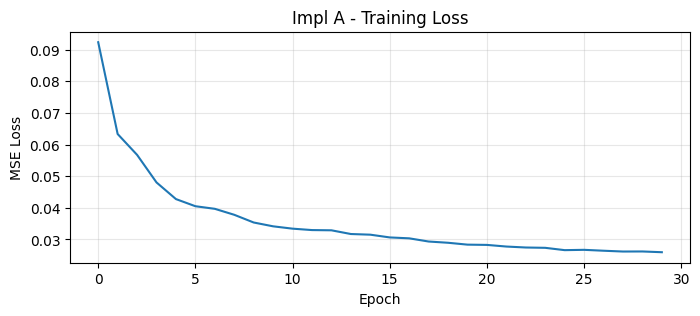

In [13]:
print('=== 实现 A: 源代码实现 — 训练 ===')
model_a = MAE()
losses_a = train_mae(model_a, train_loader, NUM_EPOCHS, LR, WEIGHT_DECAY, device)

plt.figure(figsize=(8, 3))
plt.plot(losses_a)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.title('Impl A - Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

=== 实现 A: 重建可视化 ===


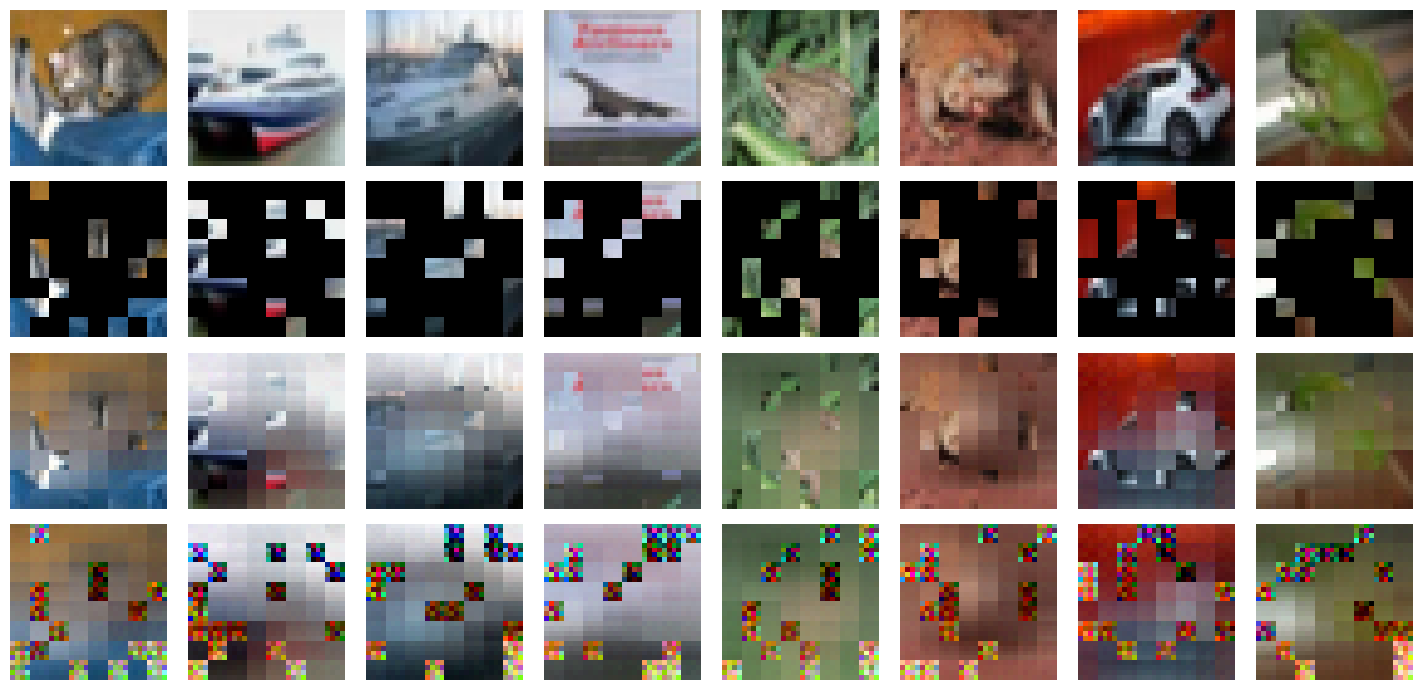

In [14]:
print('=== 实现 A: 重建可视化 ===')
visualize_mae(model_a, test_loader, device)

## 4. 实现 B — 简洁实现

用 `nn.TransformerEncoderLayer` + `nn.TransformerEncoder` 替代手写 Attention 和 Transformer Block，掩码/恢复逻辑不变。

| 源代码实现 | 简洁实现 (`nn.XXX`) |
|---|---|
| `MultiHeadSelfAttention` | `nn.TransformerEncoderLayer` 内置 |
| `TransformerBlock` | `nn.TransformerEncoderLayer(norm_first=True)` |
| `MAEEncoder.blocks` | `nn.TransformerEncoder` |
| `MAEDecoder.blocks` | `nn.TransformerEncoder` |
| `PatchEmbedding` | `nn.Conv2d`（相同） |
| `random_masking` | 相同逻辑 |

In [15]:
class MAEConcise(nn.Module):
    """简洁实现：使用 nn.TransformerEncoder 替代手写 Transformer Block"""

    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=IN_CHANNELS,
                 enc_dim=ENC_DIM, enc_heads=ENC_HEADS, enc_layers=ENC_LAYERS, enc_ff=ENC_FF,
                 dec_dim=DEC_DIM, dec_heads=DEC_HEADS, dec_layers=DEC_LAYERS, dec_ff=DEC_FF,
                 mask_ratio=MASK_RATIO):
        super().__init__()
        self.patch_size = patch_size
        self.mask_ratio = mask_ratio
        num_patches = (img_size // patch_size) ** 2

        # ── Encoder ──
        self.patch_embed = nn.Conv2d(in_channels, enc_dim, patch_size, patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, enc_dim))
        self.enc_pos = nn.Parameter(torch.zeros(1, num_patches + 1, enc_dim))
        enc_layer = nn.TransformerEncoderLayer(
            enc_dim, enc_heads, enc_ff, dropout=DROPOUT,
            activation='gelu', batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, enc_layers)
        self.enc_norm = nn.LayerNorm(enc_dim)

        # ── Decoder ──
        self.dec_embed = nn.Linear(enc_dim, dec_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, dec_dim))
        self.dec_pos = nn.Parameter(torch.zeros(1, num_patches + 1, dec_dim))
        dec_layer = nn.TransformerEncoderLayer(
            dec_dim, dec_heads, dec_ff, dropout=DROPOUT,
            activation='gelu', batch_first=True, norm_first=True)
        self.decoder = nn.TransformerEncoder(dec_layer, dec_layers)
        self.dec_norm = nn.LayerNorm(dec_dim)
        self.pred = nn.Linear(dec_dim, patch_size ** 2 * in_channels)

        # 初始化
        for p in [self.cls_token, self.enc_pos, self.mask_token, self.dec_pos]:
            nn.init.normal_(p, std=0.02)

    def patchify(self, imgs):
        p = self.patch_size
        B, C, H, W = imgs.shape
        h, w = H // p, W // p
        return imgs.reshape(B, C, h, p, w, p).permute(0,2,4,3,5,1).reshape(B, h*w, p*p*C)

    def unpatchify(self, x):
        p = self.patch_size
        B, N, _ = x.shape
        h = w = int(N ** 0.5)
        return x.reshape(B, h, w, p, p, 3).permute(0,5,1,3,2,4).reshape(B, 3, h*p, w*p)

    def forward(self, imgs):
        B = imgs.shape[0]

        # Patch embed + positional encoding
        x = self.patch_embed(imgs).flatten(2).transpose(1, 2)  # (B, N, enc_dim)
        N, D = x.shape[1], x.shape[2]
        x = x + self.enc_pos[:, 1:]

        # Random masking
        num_keep = int(N * (1 - self.mask_ratio))
        noise = torch.rand(B, N, device=x.device)
        ids_shuffle = noise.argsort(1)
        ids_restore = ids_shuffle.argsort(1)
        x = torch.gather(x, 1, ids_shuffle[:, :num_keep].unsqueeze(-1).expand(-1,-1,D))
        mask = torch.ones(B, N, device=x.device)
        mask[:, :num_keep] = 0
        mask = torch.gather(mask, 1, ids_restore)

        # CLS + Encode
        cls = (self.cls_token + self.enc_pos[:, :1]).expand(B, -1, -1)
        x = self.enc_norm(self.encoder(torch.cat([cls, x], dim=1)))  # (B, 1+N_vis, enc_dim)

        # Decode
        x = self.dec_embed(x)                             # (B, 1+N_vis, dec_dim)
        dec_dim = x.shape[-1]
        x_no_cls, mt = x[:, 1:], self.mask_token.repeat(B, N - num_keep, 1)
        x_ = torch.cat([x_no_cls, mt], dim=1)            # (B, N, dec_dim)
        x_ = torch.gather(x_, 1, ids_restore.unsqueeze(-1).expand(-1,-1,dec_dim))
        x = torch.cat([x[:, :1], x_], dim=1) + self.dec_pos
        x = self.dec_norm(self.decoder(x))
        pred = self.pred(x[:, 1:])                        # (B, N, P*P*C)

        # Loss
        target = self.patchify(imgs)
        loss = ((pred - target) ** 2).mean(-1)
        loss = (loss * mask).sum() / mask.sum().clamp(min=1)
        return loss, pred, mask

model_b = MAEConcise()
print(f'MAEConcise params: {sum(p.numel() for p in model_b.parameters()):,}')

MAEConcise params: 164,304


/tmp/ipython-input-406/2735146869.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, enc_layers)
/tmp/ipython-input-406/2735146869.py:30: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.decoder = nn.TransformerEncoder(dec_layer, dec_layers)


/tmp/ipython-input-406/2735146869.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, enc_layers)
/tmp/ipython-input-406/2735146869.py:30: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.decoder = nn.TransformerEncoder(dec_layer, dec_layers)


=== 实现 B: 简洁实现 — 训练 ===
  Epoch [  1/30]  Loss: 0.0961
  Epoch [  5/30]  Loss: 0.0442
  Epoch [ 10/30]  Loss: 0.0353
  Epoch [ 15/30]  Loss: 0.0317
  Epoch [ 20/30]  Loss: 0.0274
  Epoch [ 25/30]  Loss: 0.0262
  Epoch [ 30/30]  Loss: 0.0256


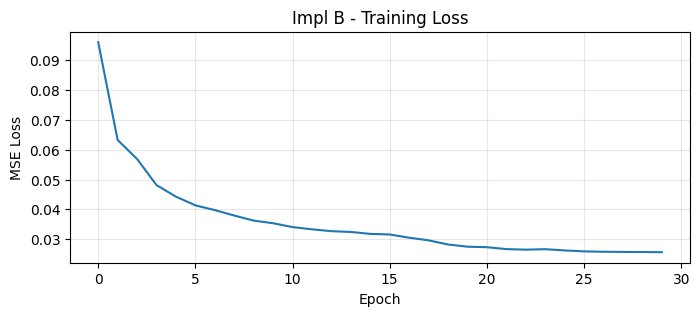

In [16]:
print('=== 实现 B: 简洁实现 — 训练 ===')
model_b = MAEConcise()
losses_b = train_mae(model_b, train_loader, NUM_EPOCHS, LR, WEIGHT_DECAY, device)

plt.figure(figsize=(8, 3))
plt.plot(losses_b)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.title('Impl B - Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

=== 实现 B: 重建可视化 ===


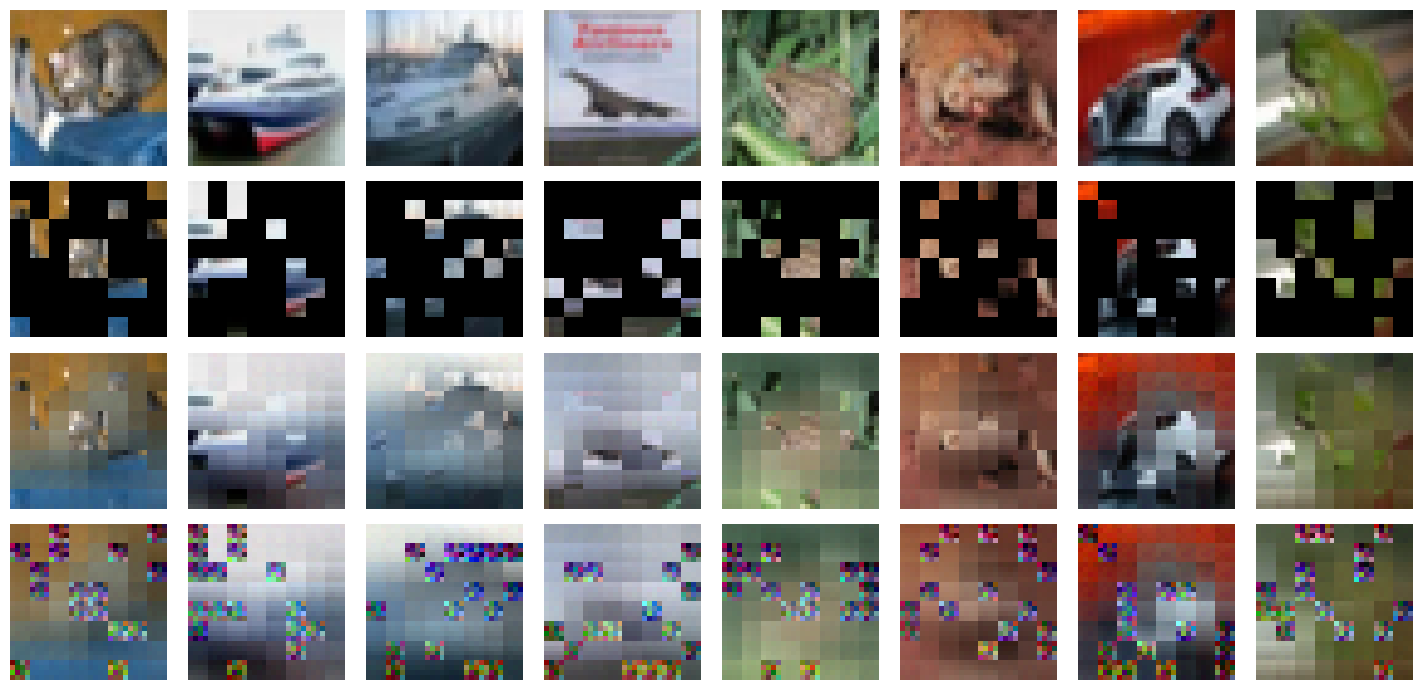

In [17]:
print('=== 实现 B: 重建可视化 ===')
visualize_mae(model_b, test_loader, device)

## 5. 结果对比

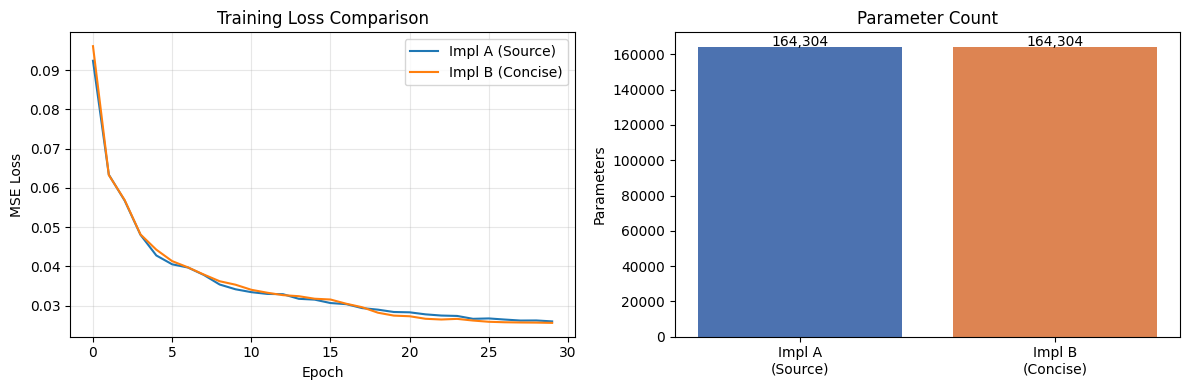

Final Loss — A: 0.0260 | B: 0.0256


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss 曲线对比
axes[0].plot(losses_a, label='Impl A (Source)')
axes[0].plot(losses_b, label='Impl B (Concise)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 参数量对比
params_a = sum(p.numel() for p in model_a.parameters())
params_b = sum(p.numel() for p in model_b.parameters())
axes[1].bar(['Impl A\n(Source)', 'Impl B\n(Concise)'], [params_a, params_b],
            color=['#4C72B0', '#DD8452'])
axes[1].set_ylabel('Parameters')
axes[1].set_title('Parameter Count')
for i, v in enumerate([params_a, params_b]):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f'Final Loss — A: {losses_a[-1]:.4f} | B: {losses_b[-1]:.4f}')

## 6. 应用：MAE 预训练编码器微调分类

MAE 预训练完成后，**丢弃解码器**，仅保留编码器。在编码器上接一个线性分类头，对 CIFAR-10 进行有监督微调。

微调时：
- `mask_ratio = 0`：编码器处理全部 64 个 Patch
- 使用 CLS token 的输出作为图像级表示
- 端到端微调编码器 + 分类头

In [19]:
class MAEClassifier(nn.Module):
    """用预训练 MAE 编码器做图像分类"""
    def __init__(self, pretrained_mae, num_classes=10):
        super().__init__()
        self.encoder = copy.deepcopy(pretrained_mae.encoder)  # 深拷贝避免修改原模型
        self.encoder.mask_ratio = 0.0   # 微调时不掩码
        enc_dim = self.encoder.norm.normalized_shape[0]
        self.head = nn.Linear(enc_dim, num_classes)

    def forward(self, x):
        features, _, _ = self.encoder(x)  # (B, 1+N, D)
        cls_token = features[:, 0]        # (B, D) — CLS token
        return self.head(cls_token)


def train_classifier(model, train_loader, test_loader, num_epochs, lr, device):
    """有监督微调训练"""
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        model.train()
        correct, total = 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss = criterion(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            model.eval()
            t_correct, t_total = 0, 0
            with torch.no_grad():
                for imgs, labels in test_loader:
                    imgs, labels = imgs.to(device), labels.to(device)
                    logits = model(imgs)
                    t_correct += (logits.argmax(1) == labels).sum().item()
                    t_total += labels.size(0)
            print(f'  Epoch [{epoch+1:>3}/{num_epochs}]  '
                  f'Train Acc: {correct/total:.4f}  Test Acc: {t_correct/t_total:.4f}')

In [20]:
# MAE 预训练 → 微调分类 vs 随机初始化
print('=== MAE 预训练编码器 → 微调分类 ===')
clf_pretrained = MAEClassifier(model_a, num_classes=10)
train_classifier(clf_pretrained, train_loader, test_loader, num_epochs=20, lr=1e-3, device=device)

print('\n=== 随机初始化编码器 → 直接分类（对照组） ===')
model_scratch = MAE()  # 未经预训练
clf_scratch = MAEClassifier(model_scratch, num_classes=10)
train_classifier(clf_scratch, train_loader, test_loader, num_epochs=20, lr=1e-3, device=device)

=== MAE 预训练编码器 → 微调分类 ===
  Epoch [  1/20]  Train Acc: 0.2612  Test Acc: 0.3080
  Epoch [  5/20]  Train Acc: 0.4930  Test Acc: 0.4580
  Epoch [ 10/20]  Train Acc: 0.6098  Test Acc: 0.4720
  Epoch [ 15/20]  Train Acc: 0.7105  Test Acc: 0.4960
  Epoch [ 20/20]  Train Acc: 0.8095  Test Acc: 0.4770

=== 随机初始化编码器 → 直接分类（对照组） ===
  Epoch [  1/20]  Train Acc: 0.1621  Test Acc: 0.2490
  Epoch [  5/20]  Train Acc: 0.4111  Test Acc: 0.4030
  Epoch [ 10/20]  Train Acc: 0.5162  Test Acc: 0.4240
  Epoch [ 15/20]  Train Acc: 0.6216  Test Acc: 0.4590
  Epoch [ 20/20]  Train Acc: 0.7226  Test Acc: 0.4430


## 面试拓展

### 高频面试题

**Q1: MAE 为什么要用 75% 这么高的掩码率，而 BERT 只用 15%？**

图像数据存在极高的空间冗余性——相邻像素高度相关，缺少少量 Patch 可通过简单插值恢复。15% 的掩码率对于图像来说任务过于简单，模型无需理解语义即可完成重建。75% 掩码率迫使模型从极少的可见信息中推断全局结构和语义，从而学到更有意义的表示。而文本中每个 token 承载独立语义，信息密度高，15% 已构成足够挑战。

**Q2: MAE 的编码器-解码器为什么要设计成非对称的？**

- **计算效率**：编码器（ViT-Large/Huge）仅处理 25% 的 Patch，计算量降为全图的 ~1/4，使大规模预训练可行
- **任务分工**：编码器专注于学习语义表示，不受重建任务干扰；解码器仅在预训练时使用，可以设计得很轻量
- **迁移性**：微调时直接丢弃解码器，编码器的表示更纯粹

**Q3: MAE 与对比学习方法（SimCLR、MoCo）相比有什么优劣？**

| 维度 | MAE | 对比学习 (SimCLR/MoCo) |
|------|-----|----------------------|
| 训练信号 | 像素级重建（生成式） | 实例级对比（判别式） |
| 数据增强 | 仅需随机掩码 | 依赖精心设计的增强组合 |
| 架构依赖 | 需要 ViT（Patch 结构） | CNN 和 ViT 均适用 |
| 计算效率 | 高（仅编码 25% Patch） | 较低（需要大 batch / 动量队列） |
| 线性探测 | 略逊于对比学习 | 线性探测性能强 |
| 微调性能 | 更优（尤其大数据集） | 稍逊 |

**Q4: MAE 为什么直接重建像素而不是像 BEiT 那样预测离散 Token？**

- 像素重建更简单，不需要额外的 tokenizer（如 dVAE）
- 论文实验表明归一化像素与 dVAE token 的性能差异不显著
- 避免了 tokenizer 引入的信息瓶颈和额外训练开销
- 更符合"简洁"的设计哲学

**Q5: MAE 和 SimMIM 的核心区别是什么？**

两者核心思想相同（掩码图像建模），关键区别在于掩码处理方式：
- **MAE**：掩码 Patch 在编码器阶段被**完全移除**，mask token 仅在解码器引入 → 编码器计算量降为 ~25%
- **SimMIM**：掩码位置用可学习的 mask token 替换后**一起送入编码器** → 编码器仍处理全部 Token
- MAE 因此训练速度快 ~3x

**Q6: 为什么 MAE 之前的掩码建模在视觉领域不成功？**

- 视觉领域长期以 CNN 为主，CNN 的卷积操作在规则网格上进行，难以自然地引入 mask token 或处理不规则输入
- ViT 的出现使得图像可以像文本一样被 tokenize（Patch → Token），为掩码建模提供了架构基础
- 此外，之前的方法未充分认识到视觉数据的高冗余性需要更高的掩码率

**Q7: MAE 的 mask token 为什么所有位置共享同一个？不会丢失位置信息吗？**

位置信息通过**位置编码**而非 mask token 本身提供。mask token 的作用是提供一个统一的"待填充"占位符，解码器通过位置编码区分每个 mask token 的空间位置。这种设计参数高效（仅需 1 个可学习向量），且实验表明效果良好。

**Q8: MAE 预训练后，线性探测和微调的性能差异为什么较大？**

MAE 的预训练任务是像素级重建，学到的表示更偏底层（纹理、形状），与高级语义（类别）存在 gap。线性探测仅训练一个线性层，无法弥合这个 gap。微调允许编码器参数更新以适应分类任务，因此性能提升显著。相比之下，对比学习直接在实例级做判别，学到的表示更语义化，线性探测就已表现良好。

### 延伸阅读与对比

| 对比维度 | MAE | BEiT | SimMIM | DINO |
|---------|-----|------|--------|------|
| 核心思想 | 掩码像素重建 | 掩码 Token 预测 | 掩码像素重建 | 自蒸馏 |
| 编码器输入 | 仅可见 Patch | 全部 Patch | 全部 Patch | 全部 Patch (双视图) |
| 重建目标 | 归一化像素 | dVAE Token | 原始像素 | — |
| 额外模块 | 无 | dVAE tokenizer | 无 | EMA 教师 |
| 训练效率 | 高（25% 编码） | 中 | 中 | 中 |

### 进阶探索方向

- **VideoMAE**：将 MAE 扩展到视频，利用时间维度冗余实现更高掩码率（90%+）
- **AudioMAE**：在音频频谱图上应用掩码建模
- **MultiMAE**：多模态输入（RGB + 深度 + 语义分割）的统一 MAE
- **MAE 与扩散模型结合**：用 MAE 编码器作为扩散模型的条件编码器